# Lab 4: Data Preprocessing and Analysis – Superstore Sales Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load Dataset

In [4]:
df = pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding='latin1')

## Explore Data

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Task 1: Data Quality Issues

In [23]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

The "Order Date" and "Ship Date" columns are stored as object data types and need to be converted into datetime format for proper analysis.

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [28]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

The date columns are now in datetime format, which means the issue has been fixed and the data is ready to use.

## Task 2: Handling Missing Values
There are no missing values in the dataset, but some values were intentionally set as missing to demonstrate how to handle them. The median was used because it is less affected by extreme values.

In [27]:
df2 = df.copy()

df2.loc[0:10, 'Sales'] = np.nan

df2['Sales'].isnull().sum()

df2['Sales'] = df2['Sales'].fillna(df2['Sales'].median())

df2['Sales'].isnull().sum()

np.int64(0)

After applying the median strategy, all missing values were successfully filled, resulting in zero missing values.

## Task 3: Outlier Detection using IQR

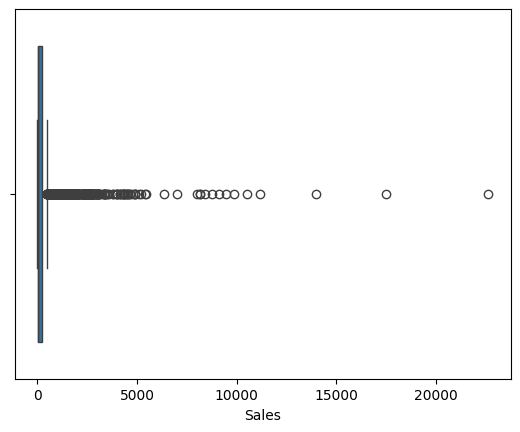

In [22]:
sns.boxplot(x=df['Sales'])
plt.show()

A boxplot of the "Sales" column shows a large number of outliers on the higher end. Most values are concentrated in a small range, while several extreme values extend far beyond the normal distribution.

### Detect Outliers using IQR

In [23]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(Q1, Q3, IQR)

17.28 209.94 192.66


### Boundaries

In [24]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-271.71000000000004 498.93


Outliers were identified using the IQR method based on the calculated boundaries.

Since the dataset contains a large number of outliers, removing them entirely could lead to significant data loss. Therefore, a capping approach was used, where extreme values were limited within the IQR boundaries.

This helps reduce the impact of outliers while preserving the overall dataset.

### Capping Outliers 

In [28]:
df['Sales'] = df['Sales'].clip(lower, upper)

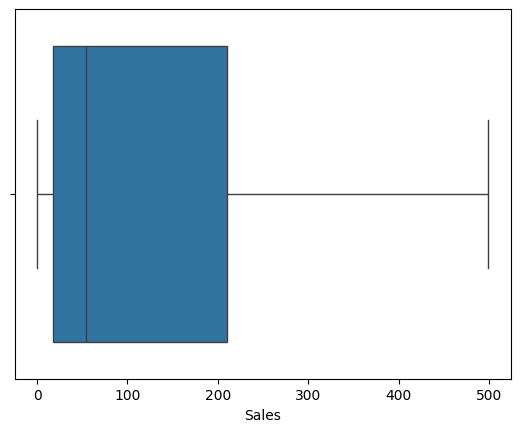

In [29]:
sns.boxplot(x=df['Sales'])
plt.show()

After applying capping, the distribution became more balanced and extreme values were limited within the defined range.

## Task 4: Normalization

Normalization is applied to scale numerical features so that they are on a similar range. This is important for machine learning models that are sensitive to the scale of data.

### Min-Max Scaling

Min-Max scaling transforms the data into a range between 0 and 1. It preserves the shape of the distribution but rescales the values.

In [32]:
from sklearn.preprocessing import MinMaxScaler

cols = ['Sales', 'Profit', 'Quantity']

# Min-Max
df_minmax = df.copy()
df_minmax[cols] = MinMaxScaler().fit_transform(df_minmax[cols])

df_minmax.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,0.524621,0.076923,0.00,0.442794
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1.000000,0.153846,0.00,0.454639
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,0.028438,0.076923,0.00,0.440458
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.000000,0.307692,0.45,0.414464
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,0.043981,0.076923,0.20,0.440168


After applying Min-Max scaling, the values are now within a range between 0 and 1, making the features easier to compare.

Both methods were applied on separate copies of the dataset to compare how each scaling technique affects the data.

### Z-score Standardization

Z-score standardization transforms the data to have a mean of 0 and a standard deviation of 1. It is useful when the data contains outliers or different scales.

In [18]:
from sklearn.preprocessing import StandardScaler
cols = ['Sales', 'Profit', 'Quantity']

# Z-score
df_zscore = df.copy()
df_zscore[cols] = StandardScaler().fit_transform(df_zscore[cols])

df_zscore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,0.051510,-0.804303,0.00,0.056593
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.805633,-0.354865,0.00,0.815054
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,-0.345368,-0.804303,0.00,-0.093002
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.167688,0.544012,0.45,-1.757484
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,-0.332935,-0.804303,0.20,-0.111593


After applying Z-score normalization, the values are centered around zero, making the features easier to compare.

## Task 5: PCA

Before applying PCA, a correlation check was performed between numerical features.

PCA is useful when features are related to each other, as it helps reduce dimensionality while keeping the most important information.

In [5]:
cols = ['Sales', 'Profit', 'Quantity']

corr = df[cols].corr()
corr

,Sales,Profit,Quantity
Sales,1.000000,0.479064,0.200795
Profit,0.479064,1.000000,0.066253
Quantity,0.200795,0.066253,1.000000


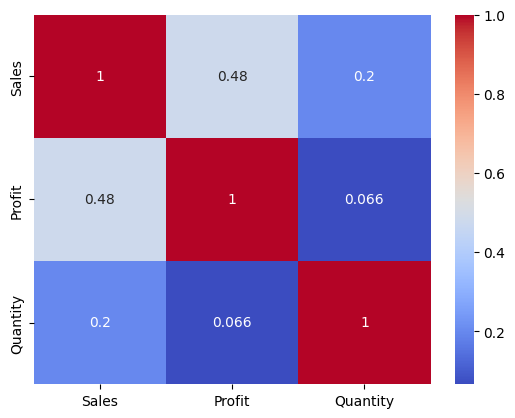

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix shows that there is a relationship between some numerical features.

Therefore, PCA was applied to reduce the number of features and remove redundancy.

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_zscore[cols])

df_pca[:5]

array([[-0.19486746, -0.76727208],
       [ 0.96258827, -0.70760681],
       [-0.56458975, -0.67487896],
       [-0.14902665,  1.0589615 ],
       [-0.56802026, -0.66898771]])

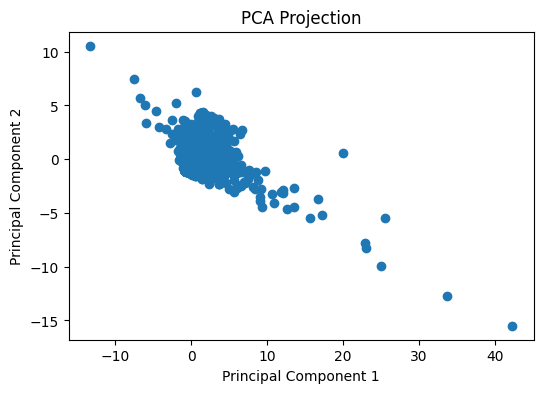

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df_pca[:,0], df_pca[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The PCA plot shows a more compact and structured distribution of the data after applying standardization.

Most data points are clustered around the center, indicating that scaling helped reduce the impact of extreme values.

A diagonal trend can also be observed, suggesting a relationship between the original features.

Overall, PCA successfully reduced the dimensionality while preserving the main patterns in the data.